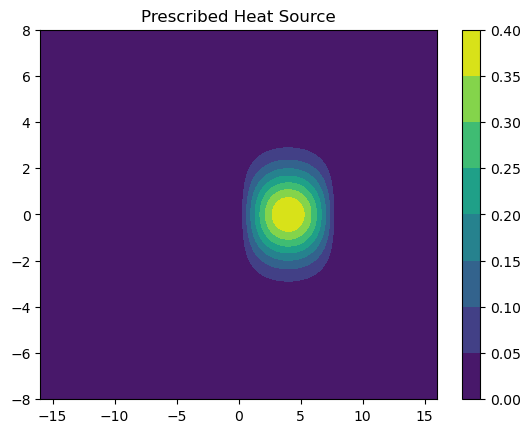

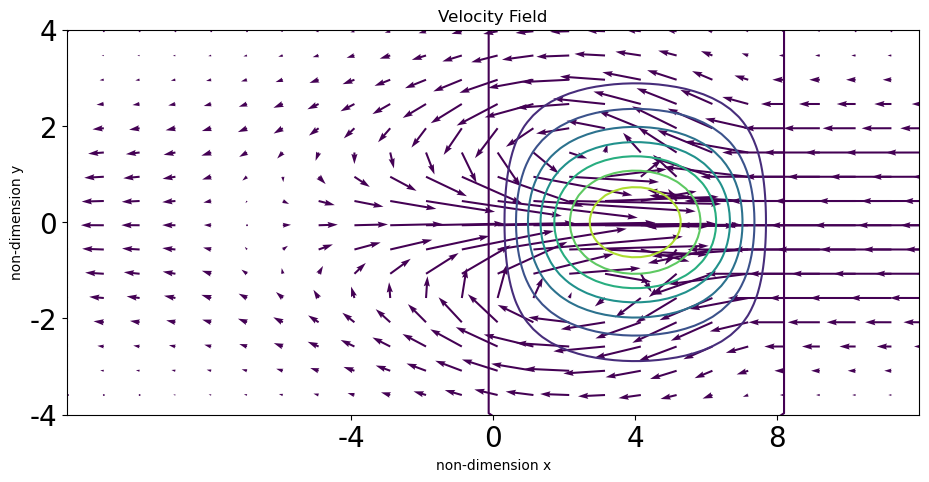

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft
from scipy.linalg import inv

# All constants
N = 128
x1, x2 = -16, 16
Lx = x2 - x1
y1, y2 = -8, 8
Ly = y2 - y1
epi1 = 0.1

# Create meshgrid
xx = np.linspace(x1, x2, N)
yy = np.linspace(y2, y1, N)
x, y = np.meshgrid(xx, yy)
y2_op = y ** 2  # create y^2 operator
dx = Lx / (N - 1)
dy = Ly / (N - 1)
Q0 = 0.4
Q = np.zeros((N, N))
epi2 = np.ones((N, N)) * epi1

#Prescribed heat source
for i in range(N):
    for j in range(N):
        if 0 <= xx[j] <= 8 and -4 <= yy[i] <= 4:
            Q[i, j] = Q0 * np.cos(np.pi * (xx[j] - 4) / 8) * np.exp(-(yy[i] )**2/ 2**2)

# Q[64,64] = 1

# Plot figure 1
plt.figure(1)
plt.contourf(x, y, Q)
plt.colorbar()
plt.title('Prescribed Heat Source')
plt.show()

# Create first and second order differentials of y
diff_y = np.zeros((N, N))
diff_yy = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i == j + 1:
            diff_y[i, j] = (0.5 + diff_y[i, j]) / dy
            diff_yy[i, j] = (1 + diff_yy[i, j]) / dy ** 2
        elif i == j - 1:
            diff_y[i, j] = (-0.5 + diff_y[i, j]) / dy
            diff_yy[i, j] = (1 + diff_yy[i, j]) / dy ** 2
        elif i == j:
            diff_y[i, j] /= dy
            diff_yy[i, j] = (-2 + diff_yy[i, j]) / dy ** 2

# Create wave number matrix
k = np.zeros(N)

for j in range(N):
    if j <= N / 2:
        k[j] = (j) * 2 * np.pi / Lx
    elif j > N / 2 + 1:
        k[j] = -(N - j) * 2 * np.pi / Lx

# FFT of Q
ImQ = np.zeros((N, N), dtype=complex)
for i in range(N):
    ImQ[i, :] = fft(Q[i, :], N)

# Matrix operations from Zebiak 1982
kk = np.zeros((N, N))
ImV = np.zeros((N, N), dtype=complex)

for j in range(N):
    A = diff_yy + ((-0.25) * y2_op + (-1) ** 0.5 / (2 * epi1) * k[j] - epi1 ** 2 + k[j] ** 2) * np.eye(N)
    B = -diff_y @ ImQ[:, j] + (-1) ** 0.5 / (2 * epi1) * k[j] * y[:, j] * ImQ[:, j]
    ImV[:, j] = inv(A) @ B

# Calculation of ImU
ImU = np.zeros((N, N), dtype=complex)
for j in range(N):
    A1 = 0.5 * epi1 * y
    A2 = (-1) ** 0.5 * k[j] * diff_y
    B = (-1) ** 0.5 * k[j]
    ImU[:, j] = (A1[:, j] * ImV[:, j] + A2 @ ImV[:, j] + B * ImQ[:, j]) / (k[j] ** 2 + epi1 ** 2)

# Inverse FFT to get U and V
V = np.zeros((N, N), dtype=complex)
for i in range(N):
    V[i, :] = ifft(ImV[i, :], N)

U = np.zeros((N, N), dtype=complex)
for i in range(N):
    U[i, :] = ifft(ImU[i, :], N)

# Plot figure 2
fig=plt.figure(2)
plt.contour(x, y, Q)
plt.quiver(x[::4, ::4], y[::4, ::4], np.real(U[::4, ::4]), np.real(V[::4, ::4]), 1, color='k', linewidth=1.1)
plt.xlim([-12, 12])
plt.ylim([-4, 4])
plt.xticks([-4, 0, 4, 8], ['-4', '0', '4', '8'], fontsize=20)
plt.yticks([-4, -2, 0, 2, 4], ['-4', '-2', '0', '2', '4'], fontsize=20)
plt.gcf().set_size_inches(11, 5)
plt.xlabel('non-dimension x')
plt.ylabel('non-dimension y')
plt.title('Velocity Field')
plt.show()
#fig.savefig('Gill.png')